In [ ]:
import os, time, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import cv2
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torchvision.transforms.functional import to_pil_image
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, top_k_accuracy_score)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {device}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.12.0.dev20260222+cu128
CUDA     : True
Device   : cuda
GPU      : NVIDIA GeForce RTX 5080


In [2]:
# Helper function to check if code is being run on Colab
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Methods to obtain data
# DATA_PATH is the default local directory for data if other methods fail (also location for Kaggle download), 
# USE_KAGGLE will download the data from Kaggle, 
# USE_DRIVE is meant for Colab and will mount your Google Drive for the data (ensure to change path below if using this)
DATA_PATH = r"C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset"
USE_KAGGLE = False
USE_DRIVE = False

# Logic for importing data based on Kaggle, Google Drive and local directory settings

from pathlib import Path

if USE_KAGGLE:
    import kagglehub

    KAGGLE_HANDLE = "maciekpopik/plantlab2realgeneralization"

    dataset_path = kagglehub.dataset_download(KAGGLE_HANDLE)
    dataset_path = Path(dataset_path)

    if is_colab():
        TARGET_DIR = Path("/content/plant_dataset")

        # Clean existing folder
        if TARGET_DIR.exists():
            shutil.rmtree(TARGET_DIR)

        # Copy from cache → /content
        shutil.copytree(dataset_path, TARGET_DIR)

        OUTDIR = str(TARGET_DIR)
    else:
        TARGET_DIR = Path(DATA_PATH)

        if not TARGET_DIR.exists():
            shutil.copytree(dataset_path, TARGET_DIR)

    OUTDIR = str(TARGET_DIR)

    print("Dataset ready at:", OUTDIR)

elif USE_DRIVE and is_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTDIR = "/content/drive/MyDrive/ENEN-645/PlantLab2RealGeneralization" # Change this according to your Google Drive organization
    print("Dataset ready at:", OUTDIR)

else:
    # Local Root dataset folder
    OUTDIR = DATA_PATH
    print("Using local dataset at:", OUTDIR)

Using local dataset at: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset


In [5]:
DATASET_ROOT = OUTDIR

SPLITS = {
    'Train'    : os.path.join(DATASET_ROOT, 'Train'),
    'Val'      : os.path.join(DATASET_ROOT, 'Val'),
    'Test_ID'  : os.path.join(DATASET_ROOT, 'Test_ID'),
    'Test_OOD' : os.path.join(DATASET_ROOT, 'Test_OOD'),
    'Few_Shot' : os.path.join(DATASET_ROOT, 'Few_Shot'),
}

print("Split verification:")
print(f"{'Split':<12} {'Exists':<8} {'Images':>8}")
print("-" * 30)
for name, path in SPLITS.items():
    exists = os.path.isdir(path)
    count  = sum(len(f) for _, _, f in os.walk(path)) if exists else 0
    status = "✓" if exists else "✗ NOT FOUND"
    print(f"  {name:<10} {status:<8} {count:>8,}")

Split verification:
Split        Exists     Images
------------------------------
  Train      ✓          27,694
  Val        ✓           5,940
  Test_ID    ✓           5,929
  Test_OOD   ✓           2,374
  Few_Shot   ✓             300


Dataset Statistics & Class Distribution

Before training, inspecting the class distribution across all splits to understand:
- Whether classes are balanced (important for sampler choice)
- Whether `Test_OOD` has the same classes as `Train` (required for evaluation)
- The total dataset size

Number of classes : 30

Class                                           Train     OOD
--------------------------------------------------------------
  Apple___Apple_scab                              441      70
  Apple___Cedar_apple_rust                        193      71
  Apple___healthy                               1,151      74
  Blueberry___healthy                           1,052      93
  Cherry___healthy                                598      43
  Corn_(maize)___healthy                          814      85
  Corn___Cercospora_leaf_spot                     359      59
  Corn___Common_rust                              834      98
  Corn___Northern_Leaf_Blight                     689     161
  Grape___Black_rot                               826      50
  Grape___Esca_(Black_Measles)                    968      85
  Grape___healthy                                 296      74
  Peach___healthy                                 252      93
  Pepper,_bell___Bacterial_spot              

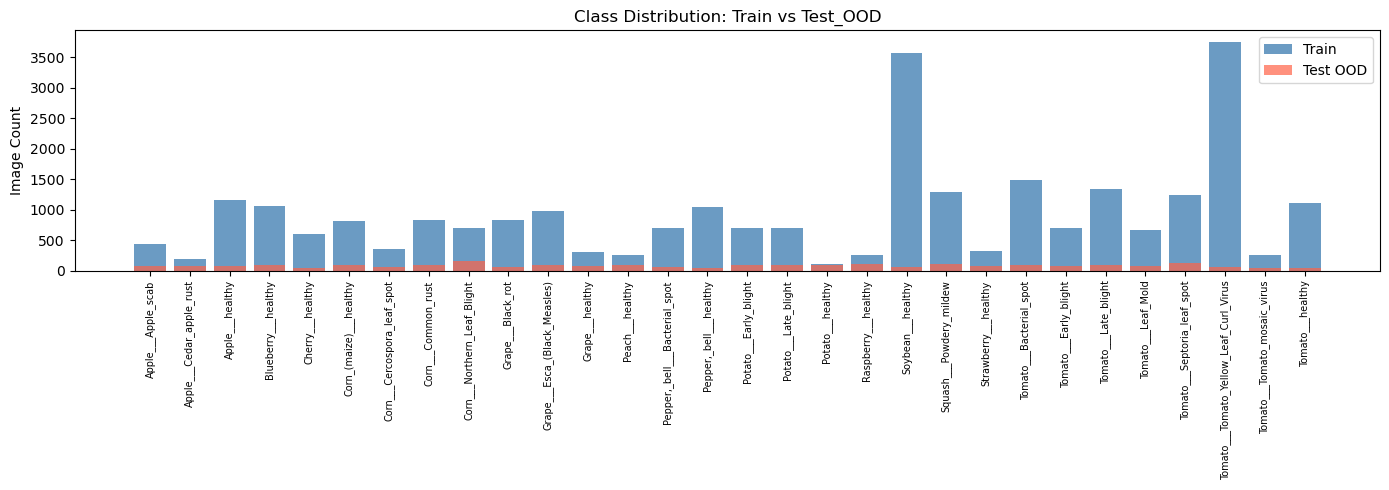

In [6]:
def count_classes(folder):
    """Returns dict of {class_name: image_count}."""
    if not os.path.isdir(folder):
        return {}
    ds = datasets.ImageFolder(folder)
    counts = Counter(ds.targets)
    return {ds.classes[k]: v for k, v in sorted(counts.items())}

train_counts = count_classes(SPLITS['Train'])
ood_counts   = count_classes(SPLITS['Test_OOD'])

CLASS_NAMES = list(train_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of classes : {NUM_CLASSES}")
print(f"\n{'Class':<45} {'Train':>7} {'OOD':>7}")
print("-" * 62)
for cls in CLASS_NAMES:
    t = train_counts.get(cls, 0)
    o = ood_counts.get(cls, 0)
    print(f"  {cls:<43} {t:>7,} {o:>7,}")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x = range(NUM_CLASSES)
ax.bar(x, [train_counts.get(c, 0) for c in CLASS_NAMES],
       label='Train', color='steelblue', alpha=0.8)
ax.bar(x, [ood_counts.get(c,   0) for c in CLASS_NAMES],
       label='Test OOD', color='tomato', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_ylabel('Image Count'); ax.set_title('Class Distribution: Train vs Test_OOD')
ax.legend(); plt.tight_layout(); plt.show()

Compute Normalization Statistics

Normalization statistics (mean and std per channel) are computed **only from the
Train split**.
to avoid
data leakage. PlantVillage has a very different color distribution from ImageNet
(mostly green leaves on white backgrounds), so dataset-specific stats are important.

mathematical approach:
Var(x) = E(x^2) - (E[x])^2

In [7]:
RECALCULATE_STATS = False

def compute_mean_std(folder, img_size=224, batch_size=256, num_workers=4):
    t = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])
    ds     = datasets.ImageFolder(folder, transform=t)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    mean    = torch.zeros(3)
    mean_sq = torch.zeros(3)
    n       = 0

    for imgs, _ in loader:
        b        = imgs.size(0) * imgs.size(2) * imgs.size(3)  # pixels per channel
        mean    += imgs.mean(dim=[0, 2, 3])       * b
        mean_sq += (imgs ** 2).mean(dim=[0, 2, 3]) * b
        n       += b

    mean    /= n
    mean_sq /= n
    std = torch.sqrt(mean_sq - mean ** 2)

    return mean.tolist(), std.tolist()

if RECALCULATE_STATS:
    print("Computing normalization statistics from Train split...")
    NORM_MEAN, NORM_STD = compute_mean_std(SPLITS['Train'])

else:
    print("Reusing pre-computed normalization statistics from Train split...")
    NORM_MEAN = torch.tensor([0.4689, 0.4986, 0.4264])
    NORM_STD = torch.tensor([0.1921, 0.1625, 0.2032])

print(f"\n Mean : {[round(m.item(), 4) for m in NORM_MEAN]}")
print(f" Std  : {[round(s.item(), 4) for s in NORM_STD]}")
print("\nImageNet defaults for comparison:")
print(f"  Mean : [0.485, 0.456, 0.406]")
print(f"  Std  : [0.229, 0.224, 0.225]")

Reusing pre-computed normalization statistics from Train split...

 Mean : [0.4689, 0.4986, 0.4264]
 Std  : [0.1921, 0.1625, 0.2032]

ImageNet defaults for comparison:
  Mean : [0.485, 0.456, 0.406]
  Std  : [0.229, 0.224, 0.225]


Data Transforms

Three transform pipelines are defined:

| Pipeline | Used For | Augmentations |
|---|---|---|
| `train_transform` | Train split | Heavy — targets the lab→field domain gap |
| `eval_transform` | Val, Test_ID, Test_OOD | Clean — resize + normalize only |
| `tta_transform` | Test-time augmentation | Light random flips + color jitter |

**Why heavy augmentation?** The domain gap between PlantVillage (white background, studio
lighting) and PlantDoc (real field images, varied backgrounds) is large. Simulating field
conditions during training, blur, perspective distortion, occlusion, and color variation,
encourages the model to learn features that transfer.

In [8]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),         # zoom variation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.15),                 # lighting variation
    transforms.RandomGrayscale(p=0.05),                               # overexposure sim
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),         # focus blur
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),        # angle variation
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),              # occlusion
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

tta_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

print("Transforms defined:")
print(f"  train_transform : {len(train_transform.transforms)} operations")
print(f"  eval_transform  : {len(eval_transform.transforms)} operations")
print(f"  tta_transform   : {len(tta_transform.transforms)} operations")

Transforms defined:
  train_transform : 11 operations
  eval_transform  : 3 operations
  tta_transform   : 5 operations


 Datasets & DataLoaders

A `WeightedRandomSampler` is used for the training loader to handle class imbalance,
PlantVillage has significantly more images for healthy leaves than for some disease
classes. This ensures each class is seen roughly equally during training.

> **Note:** `Few_Shot` does not get a loader here, it's only used if fine-tuning is
triggered in the final section.

In [9]:
BATCH_SIZE   = 64
NUM_WORKERS  = 4

train_dataset    = datasets.ImageFolder(SPLITS['Train'],    transform=train_transform)
val_dataset      = datasets.ImageFolder(SPLITS['Val'],      transform=eval_transform)
test_id_dataset  = datasets.ImageFolder(SPLITS['Test_ID'],  transform=eval_transform)
test_ood_dataset = datasets.ImageFolder(SPLITS['Test_OOD'], transform=eval_transform)

# Sanity check: class names must match across splits
assert train_dataset.classes == val_dataset.classes, \
    "Class mismatch between Train and Val!"

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"{'Split':<12} {'Images':>8}  {'Classes':>8}")
print("-" * 32)
for name, ds in [('Train', train_dataset), ('Val', val_dataset),
                  ('Test_ID', test_id_dataset), ('Test_OOD', test_ood_dataset)]:
    print(f"  {name:<10} {len(ds):>8,}  {len(ds.classes):>8}")

def make_weighted_sampler(dataset):
    targets       = torch.tensor(dataset.targets)
    class_counts  = torch.bincount(targets)
    class_weights = 1.0 / class_counts.float()
    sample_wts    = class_weights[targets]
    return WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

train_loader    = DataLoader(train_dataset,    batch_size=BATCH_SIZE,
                             sampler=make_weighted_sampler(train_dataset),
                             num_workers=NUM_WORKERS, pin_memory=True)
val_loader      = DataLoader(val_dataset,      batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
test_id_loader  = DataLoader(test_id_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
test_ood_loader = DataLoader(test_ood_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders ready  |  Batch size: {BATCH_SIZE}  |  Workers: {NUM_WORKERS}")

Split          Images   Classes
--------------------------------
  Train        27,694        30
  Val           5,940        30
  Test_ID       5,929        30
  Test_OOD      2,374        30

DataLoaders ready  |  Batch size: 64  |  Workers: 4


Model Architecture

**Base:** ResNet-50 pretrained on ImageNet (V2 weights — stronger than V1).

**Custom head** replaces the default single linear layer with a deeper classifier:

Dropout(0.5) → Linear(2048→512) → BatchNorm → ReLU → Dropout(0.3) → Linear(512→C)

**Why this head?** A 2-layer head with BatchNorm and two dropout stages is more
resistant to overfitting on PlantVillage and generalizes better to OOD data than
a single linear layer.

The backbone is **fully frozen** at initialization. Layers are progressively
unfrozen across 3 training phases.

In [10]:
def build_model(num_classes: int, dropout: float = 0.5) -> nn.Module:
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False          # freeze entire backbone
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model

model     = build_model(NUM_CLASSES).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f"Model        : ResNet-50 (ImageNet V2 weights)")
print(f"Head         : Linear(2048→512→{NUM_CLASSES})")
print(f"Parameters   : {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)")

Model        : ResNet-50 (ImageNet V2 weights)
Head         : Linear(2048→512→30)
Parameters   : 1,065,502 trainable / 24,573,534 total (4.3%)


Training Utilities

This section defines all helper functions needed for training:

| Function | Purpose |
|---|---|
| `set_trainable_layers` | Freeze/unfreeze specific ResNet layer groups |
| `EarlyStopping` | Stop training when validation loss plateaus; saves best weights |
| `train_one_epoch` | One full pass over the training set with mixed precision |
| `evaluate_loader` | Compute loss and accuracy on any loader |
| `train_phase` | Run a full training phase with early stopping |
| `plot_history` | Plot loss and accuracy curves across all phases |

In [11]:
def set_trainable_layers(model, layer_names: list):
    """Unfreeze named layer groups; freeze everything else."""
    for param in model.parameters():
        param.requires_grad = False
    for name in layer_names:
        for param in getattr(model, name).parameters():
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Unfrozen: {layer_names}  →  "
          f"{trainable:,} / {total:,} params ({100*trainable/total:.1f}%)")


class EarlyStopping:
    def __init__(self, patience: int = 8, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum, correct = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return loss_sum / n, correct / n


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    loss_sum, correct = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device.type):
            out  = model(imgs)
            loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return loss_sum / n, correct / n


def train_phase(model, train_loader, val_loader, criterion, optimizer,
                scheduler, scaler, early_stopping, max_epochs, phase_name):
    print(f"\n{'='*65}\n  {phase_name}\n{'='*65}")
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                          optimizer, scaler)
        va_loss, va_acc = evaluate_loader(model, val_loader, criterion)

        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va_loss)
        else:
            scheduler.step()

        for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc]):
            history[k].append(v)

        improved = va_loss <= early_stopping.best_loss
        tag = ' ✓ improved' if improved else \
              f' [{early_stopping.counter}/{early_stopping.patience}]'
        print(f"  Ep {epoch:3d}/{max_epochs}  "
              f"train {tr_loss:.4f}/{tr_acc:.4f}  "
              f"val {va_loss:.4f}/{va_acc:.4f}  "
              f"({time.time()-t0:.0f}s){tag}")

        if early_stopping.step(va_loss, model):
            print(f"\n  Early stopping triggered after {epoch} epochs.")
            break

    model.load_state_dict(early_stopping.best_state)
    print(f"  Best val loss: {early_stopping.best_loss:.4f}")
    return history


def plot_history(histories: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    for i, (name, h) in enumerate(histories.items()):
        ep = range(1, len(h['train_loss']) + 1)
        c  = colors[i % len(colors)]
        ax1.plot(ep, h['train_loss'], '--', color=c, alpha=0.5, linewidth=1.2)
        ax1.plot(ep, h['val_loss'],   '-',  color=c, linewidth=2, label=name)
        ax2.plot(ep, h['train_acc'],  '--', color=c, alpha=0.5, linewidth=1.2)
        ax2.plot(ep, h['val_acc'],    '-',  color=c, linewidth=2, label=name)
    for ax, ylabel in [(ax1, 'Loss'), (ax2, 'Accuracy')]:
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
        ax.set_title(f'{ylabel}  (solid = val, dashed = train)')
    plt.suptitle('Training Curves — All Phases', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


print("All training utilities defined.")

All training utilities defined.


Phase 1 — Train the FC Head Only

**Strategy:** Only the new classification head (`fc`) is trainable. The entire
ResNet-50 backbone remains frozen.

**Why start here?** Randomly initialized head weights can produce large gradients
that would damage pretrained backbone features if the backbone were unfrozen
immediately. Warming up the head first stabilizes training.

- **Optimizer:** AdamW (weight decay = 0.01)
- **LR:** 1e-3 (head only)  
- **Scheduler:** ReduceLROnPlateau (halves LR when val loss plateaus)
- **Max epochs:** 30 (early stopping with patience 8)

In [12]:
criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)
#scaler        = GradScaler(device_type=device.type)
scaler = GradScaler()
all_histories = {}

set_trainable_layers(model, ['fc'])

opt_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01
)
sched_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    opt_p1, mode='min', factor=0.5, patience=3#, verbose=True
)
es_p1 = EarlyStopping(patience=8)

all_histories['Phase 1 (FC)'] = train_phase(
    model, train_loader, val_loader, criterion,
    opt_p1, sched_p1, scaler, es_p1,
    max_epochs=30, phase_name='Phase 1 — FC Head Only'
)

  Unfrozen: ['fc']  →  1,065,502 / 24,573,534 params (4.3%)

  Phase 1 — FC Head Only
  Ep   1/30  train 1.6828/0.6528  val 1.1859/0.8458  (88s) ✓ improved
  Ep   2/30  train 1.4395/0.7328  val 1.1423/0.8608  (90s) ✓ improved
  Ep   3/30  train 1.3946/0.7519  val 1.0994/0.8749  (90s) ✓ improved
  Ep   4/30  train 1.3737/0.7591  val 1.0922/0.8689  (90s) ✓ improved
  Ep   5/30  train 1.3519/0.7672  val 1.1047/0.8572  (91s) [0/8]
  Ep   6/30  train 1.3270/0.7781  val 1.1032/0.8579  (90s) [1/8]
  Ep   7/30  train 1.3334/0.7742  val 1.0966/0.8625  (91s) [2/8]
  Ep   8/30  train 1.3110/0.7847  val 1.0625/0.8798  (90s) ✓ improved
  Ep   9/30  train 1.3056/0.7850  val 1.0596/0.8879  (91s) ✓ improved
  Ep  10/30  train 1.2994/0.7840  val 1.0587/0.8791  (91s) ✓ improved
  Ep  11/30  train 1.3008/0.7872  val 1.0336/0.8966  (91s) ✓ improved
  Ep  12/30  train 1.2873/0.7933  val 1.0473/0.8911  (91s) [0/8]
  Ep  13/30  train 1.2972/0.7849  val 1.0682/0.8734  (92s) [1/8]
  Ep  14/30  train 1.2826/0.7

Phase 2 — Unfreeze layer4

**Strategy:** Unfreeze the last residual block (`layer4`) alongside the head.
These are the highest-level semantic features in ResNet — adapting them to
plant disease patterns is crucial for good transfer.

**Differential learning rates** are used to prevent overwriting the pretrained
features too aggressively:

| Layer group | LR |
|---|---|
| `layer4` | 1e-4 (conservative) |
| `fc` | 5e-4 (faster, already warmed up) |

- **Scheduler:** CosineAnnealingWarmRestarts (smooth LR cycling)
- **Max epochs:** 25

In [13]:
set_trainable_layers(model, ['layer4', 'fc'])

opt_p2 = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 5e-4},
], weight_decay=0.01)

sched_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_p2, T_0=10, T_mult=2, eta_min=1e-6
)
es_p2 = EarlyStopping(patience=8)

all_histories['Phase 2 (layer4)'] = train_phase(
    model, train_loader, val_loader, criterion,
    opt_p2, sched_p2, scaler, es_p2,
    max_epochs=25, phase_name='Phase 2 — Unfreeze layer4'
)

  Unfrozen: ['layer4', 'fc']  →  16,030,238 / 24,573,534 params (65.2%)

  Phase 2 — Unfreeze layer4
  Ep   1/25  train 1.0688/0.8826  val 0.8504/0.9648  (92s) ✓ improved
  Ep   2/25  train 0.9506/0.9246  val 0.8074/0.9690  (92s) ✓ improved
  Ep   3/25  train 0.9017/0.9400  val 0.7625/0.9823  (91s) ✓ improved
  Ep   4/25  train 0.8653/0.9491  val 0.7443/0.9818  (90s) ✓ improved
  Ep   5/25  train 0.8317/0.9588  val 0.7329/0.9840  (91s) ✓ improved
  Ep   6/25  train 0.8158/0.9606  val 0.7196/0.9855  (92s) ✓ improved
  Ep   7/25  train 0.8021/0.9641  val 0.7100/0.9872  (91s) ✓ improved
  Ep   8/25  train 0.7980/0.9643  val 0.7041/0.9882  (91s) ✓ improved
  Ep   9/25  train 0.7867/0.9668  val 0.7023/0.9884  (92s) ✓ improved
  Ep  10/25  train 0.7843/0.9690  val 0.7016/0.9892  (92s) ✓ improved
  Ep  11/25  train 0.7943/0.9655  val 0.7010/0.9886  (92s) ✓ improved
  Ep  12/25  train 0.7827/0.9669  val 0.6934/0.9899  (92s) ✓ improved
  Ep  13/25  train 0.7661/0.9717  val 0.7001/0.9830  (92s) 

Phase 3 — Unfreeze layer3 + layer4

**Strategy:** Unfreeze mid-level features (`layer3`) for full fine-tuning of
the top half of ResNet. Three-level differential LR prevents catastrophic
forgetting of low-level texture features (still in frozen layer1/layer2).

| Layer group | LR |
|---|---|
| `layer3` | 1e-5 (very conservative) |
| `layer4` | 5e-5 |
| `fc` | 2e-4 |

- **Scheduler:** CosineAnnealingWarmRestarts
- **Max epochs:** 20 (tighter patience = 6 to avoid overfit)

After this phase, training curves for all 3 phases are plotted.

  Unfrozen: ['layer3', 'layer4', 'fc']  →  23,128,606 / 24,573,534 params (94.1%)

  Phase 3 — Unfreeze layer3+4
  Ep   1/20  train 0.7071/0.9853  val 0.6657/0.9939  (95s) ✓ improved
  Ep   2/20  train 0.7068/0.9853  val 0.6663/0.9933  (94s) [0/6]
  Ep   3/20  train 0.7046/0.9864  val 0.6616/0.9949  (94s) ✓ improved
  Ep   4/20  train 0.6986/0.9884  val 0.6646/0.9929  (94s) [0/6]
  Ep   5/20  train 0.6973/0.9887  val 0.6643/0.9928  (94s) [1/6]
  Ep   6/20  train 0.6952/0.9889  val 0.6629/0.9939  (95s) [2/6]
  Ep   7/20  train 0.6914/0.9905  val 0.6606/0.9953  (94s) ✓ improved
  Ep   8/20  train 0.6909/0.9901  val 0.6605/0.9943  (94s) ✓ improved
  Ep   9/20  train 0.6893/0.9914  val 0.6609/0.9941  (94s) [1/6]
  Ep  10/20  train 0.6877/0.9920  val 0.6597/0.9946  (94s) ✓ improved
  Ep  11/20  train 0.6941/0.9892  val 0.6657/0.9926  (93s) [0/6]
  Ep  12/20  train 0.6953/0.9892  val 0.6614/0.9953  (94s) [1/6]
  Ep  13/20  train 0.6960/0.9875  val 0.6598/0.9944  (94s) [2/6]
  Ep  14/20  trai

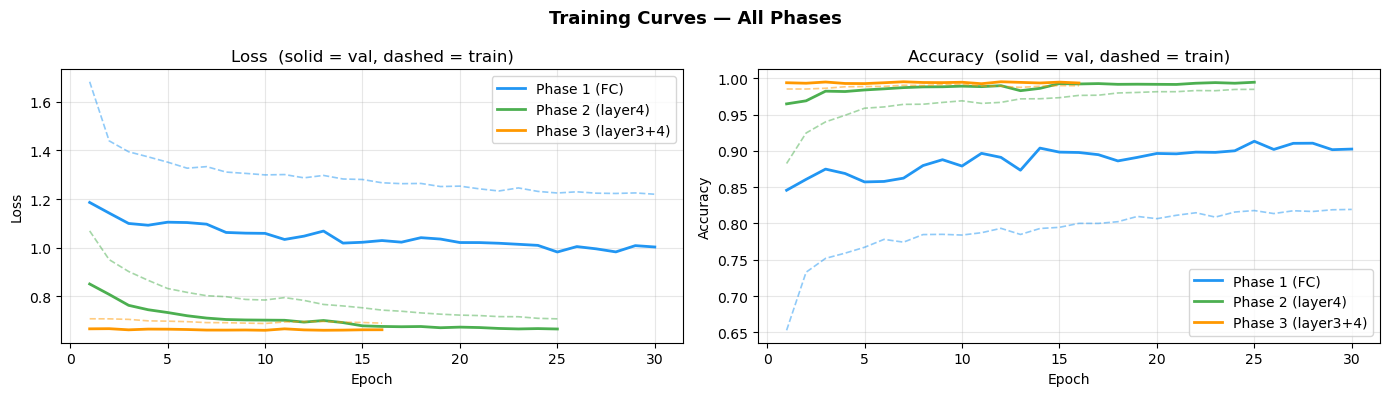

In [14]:
set_trainable_layers(model, ['layer3', 'layer4', 'fc'])

opt_p3 = optim.AdamW([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 5e-5},
    {'params': model.fc.parameters(),     'lr': 2e-4},
], weight_decay=0.01)

sched_p3 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_p3, T_0=10, T_mult=2, eta_min=1e-7
)
es_p3 = EarlyStopping(patience=6)

all_histories['Phase 3 (layer3+4)'] = train_phase(
    model, train_loader, val_loader, criterion,
    opt_p3, sched_p3, scaler, es_p3,
    max_epochs=20, phase_name='Phase 3 — Unfreeze layer3+4'
)

# Plot all phases together
plot_history(all_histories)

Evaluation Functions

Two evaluation modes are implemented:

**Standard evaluation** — single forward pass per image, fast.

**Test-Time Augmentation (TTA × 7)** — each test image is augmented 7 times and
predictions are averaged. This reduces variance and typically improves OOD accuracy
by 2–5% because it simulates the range of real-world image variations.

Results include:
- Top-1 and Top-5 accuracy
- Full per-class classification report
- Confusion matrix heatmap

In [15]:
@torch.no_grad()
def full_evaluation(model, loader, class_names, split_name='Test',
                    use_tta=False, tta_n=7):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    if use_tta:
        ds = loader.dataset
        for img_path, label in ds.imgs:
            img   = ds.loader(img_path)
            probs = torch.zeros(len(class_names), device=device)
            for _ in range(tta_n):
                t = tta_transform(img).unsqueeze(0).to(device)
                with autocast(device_type=device.type):
                    probs += torch.softmax(model(t).squeeze(), dim=0)
            probs /= tta_n
            all_probs.append(probs.cpu())
            all_preds.append(probs.argmax().item())
            all_labels.append(label)
    else:
        for imgs, labels in loader:
            imgs = imgs.to(device)
            with autocast(device_type=device.type):
                out   = model(imgs)
                probs = torch.softmax(out, dim=1)
            all_probs.extend(probs.cpu().tolist())
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())

    probs_np = np.array([p.numpy() if hasattr(p, 'numpy') else p for p in all_probs])
    top1 = accuracy_score(all_labels, all_preds)
    top5 = top_k_accuracy_score(all_labels, probs_np,
                                 k=min(5, len(class_names)),
                                 labels=list(range(len(class_names))))
    tag = f' (TTA ×{tta_n})' if use_tta else ''
    print(f"\n{'='*60}")
    print(f"  {split_name}{tag}")
    print(f"{'='*60}")
    print(f"  Top-1 Accuracy : {top1:.4f}  ({100*top1:.2f}%)")
    print(f"  Top-5 Accuracy : {top5:.4f}  ({100*top5:.2f}%)")
    print(f"\n{classification_report(all_labels, all_preds, target_names=class_names, digits=4)}")

    # Confusion matrix
    cm  = confusion_matrix(all_labels, all_preds)
    sz  = max(10, NUM_CLASSES // 2)
    fig, ax = plt.subplots(figsize=(sz, sz))
    sns.heatmap(cm, annot=(NUM_CLASSES <= 20), fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(f'Confusion Matrix — {split_name}{tag}', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout(); plt.show()

    return {
        'top1': top1, 'top5': top5,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs
    }

print("Evaluation functions defined.")

Evaluation functions defined.


Evaluations

Three evaluations are run in sequence:

1. **Test_ID** — In-distribution (PlantVillage held-out). Measures the model's
   best-case performance on data from the same distribution as training.

2. **Test_OOD** — Out-of-distribution (PlantDoc + field data). This is the **key
   metric** for the project — measures real-world generalization.

3. **Test_OOD + TTA** — Same OOD data but with Test-Time Augmentation to boost
   robustness.


  Test-ID  (PlantVillage in-dist)
  Top-1 Accuracy : 0.9948  (99.48%)
  Top-5 Accuracy : 1.0000  (100.00%)

                                        precision    recall  f1-score   support

                    Apple___Apple_scab     1.0000    1.0000    1.0000        94
              Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                       Apple___healthy     1.0000    1.0000    1.0000       247
                   Blueberry___healthy     1.0000    1.0000    1.0000       225
                      Cherry___healthy     1.0000    1.0000    1.0000       128
                Corn_(maize)___healthy     1.0000    1.0000    1.0000       174
           Corn___Cercospora_leaf_spot     0.8690    0.9481    0.9068        77
                    Corn___Common_rust     1.0000    0.9944    0.9972       179
           Corn___Northern_Leaf_Blight     0.9718    0.9324    0.9517       148
                     Grape___Black_rot     1.0000    0.9944    0.9972       177
          

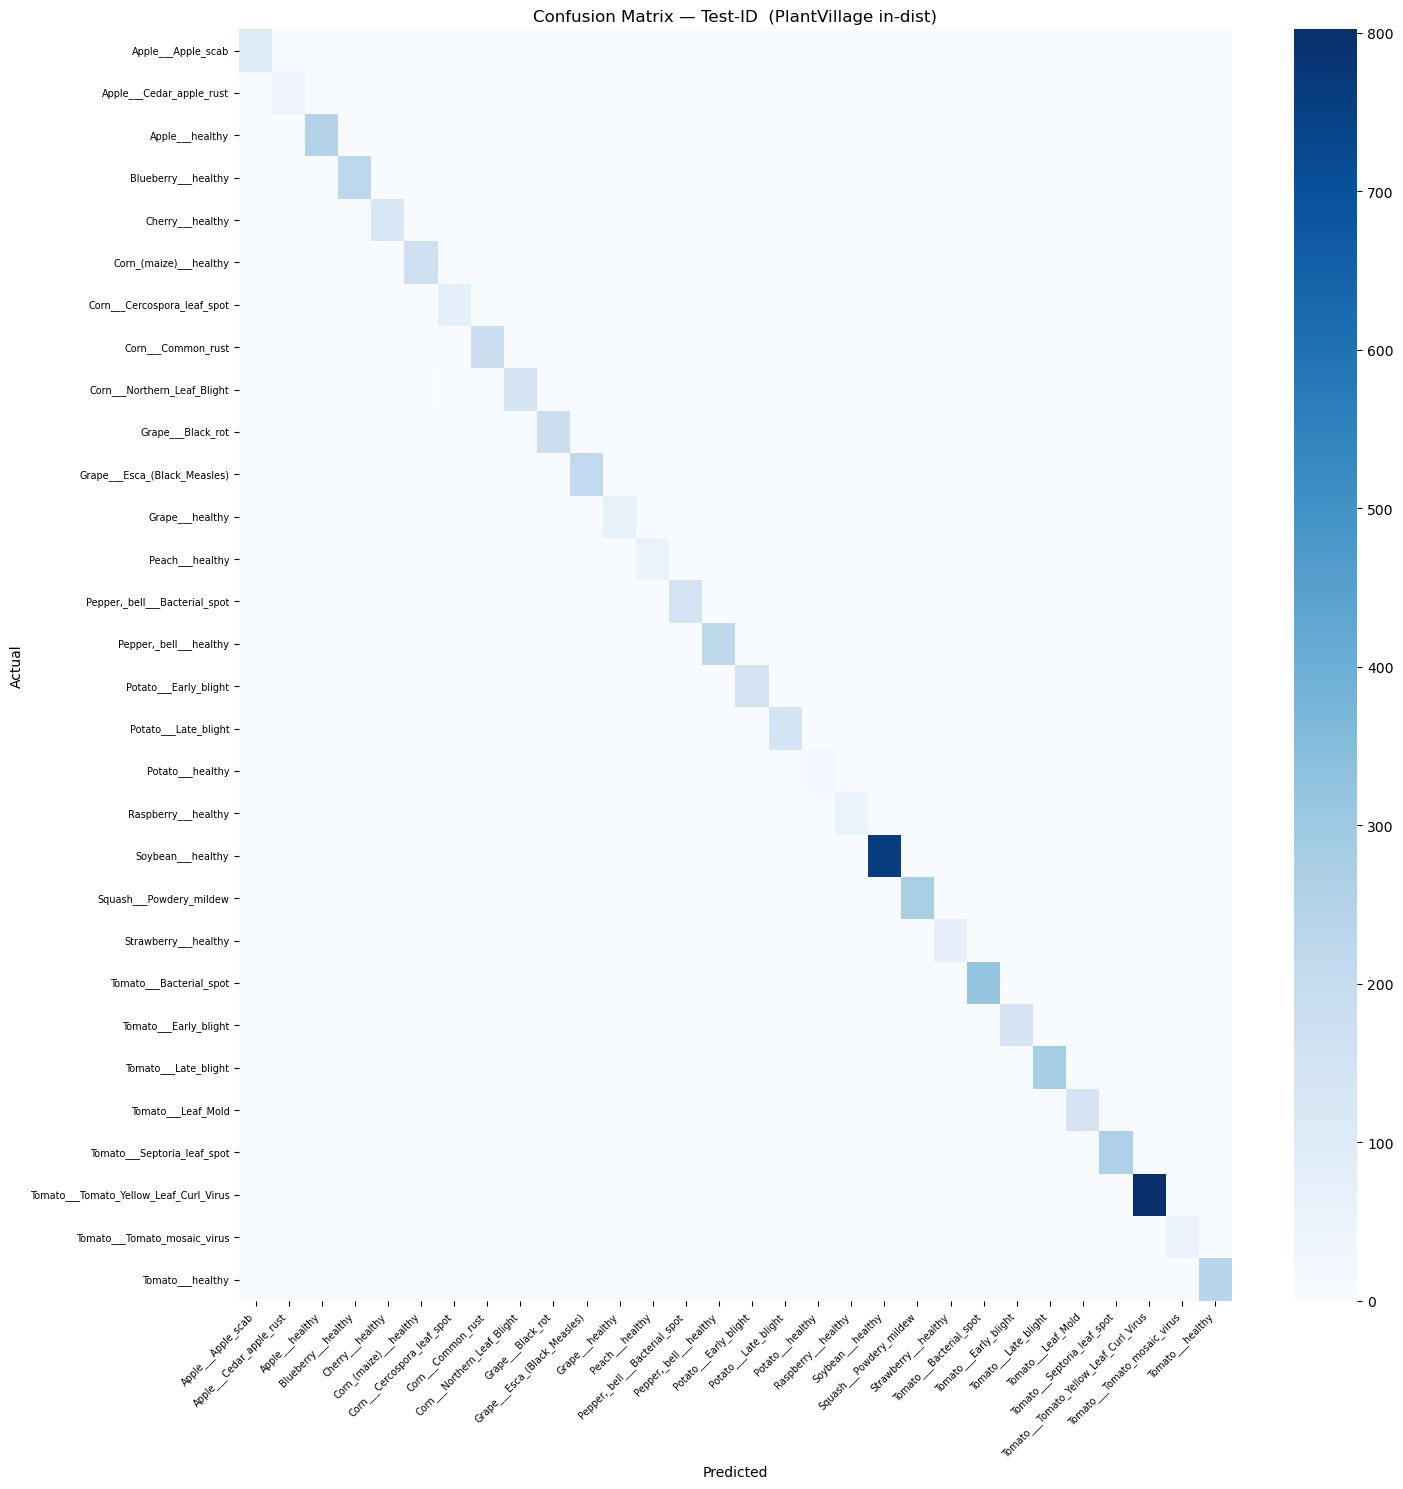


  Test-OOD (PlantDoc out-of-dist)
  Top-1 Accuracy : 0.2578  (25.78%)
  Top-5 Accuracy : 0.5733  (57.33%)

                                        precision    recall  f1-score   support

                    Apple___Apple_scab     0.7059    0.1714    0.2759        70
              Apple___Cedar_apple_rust     0.7857    0.1549    0.2588        71
                       Apple___healthy     0.5714    0.1622    0.2526        74
                   Blueberry___healthy     0.1781    0.1398    0.1566        93
                      Cherry___healthy     0.0046    0.0233    0.0077        43
                Corn_(maize)___healthy     0.6667    0.3294    0.4409        85
           Corn___Cercospora_leaf_spot     0.2642    0.8644    0.4048        59
                    Corn___Common_rust     0.5455    0.0612    0.1101        98
           Corn___Northern_Leaf_Blight     0.6923    0.3354    0.4519       161
                     Grape___Black_rot     0.0968    0.6000    0.1667        50
          G

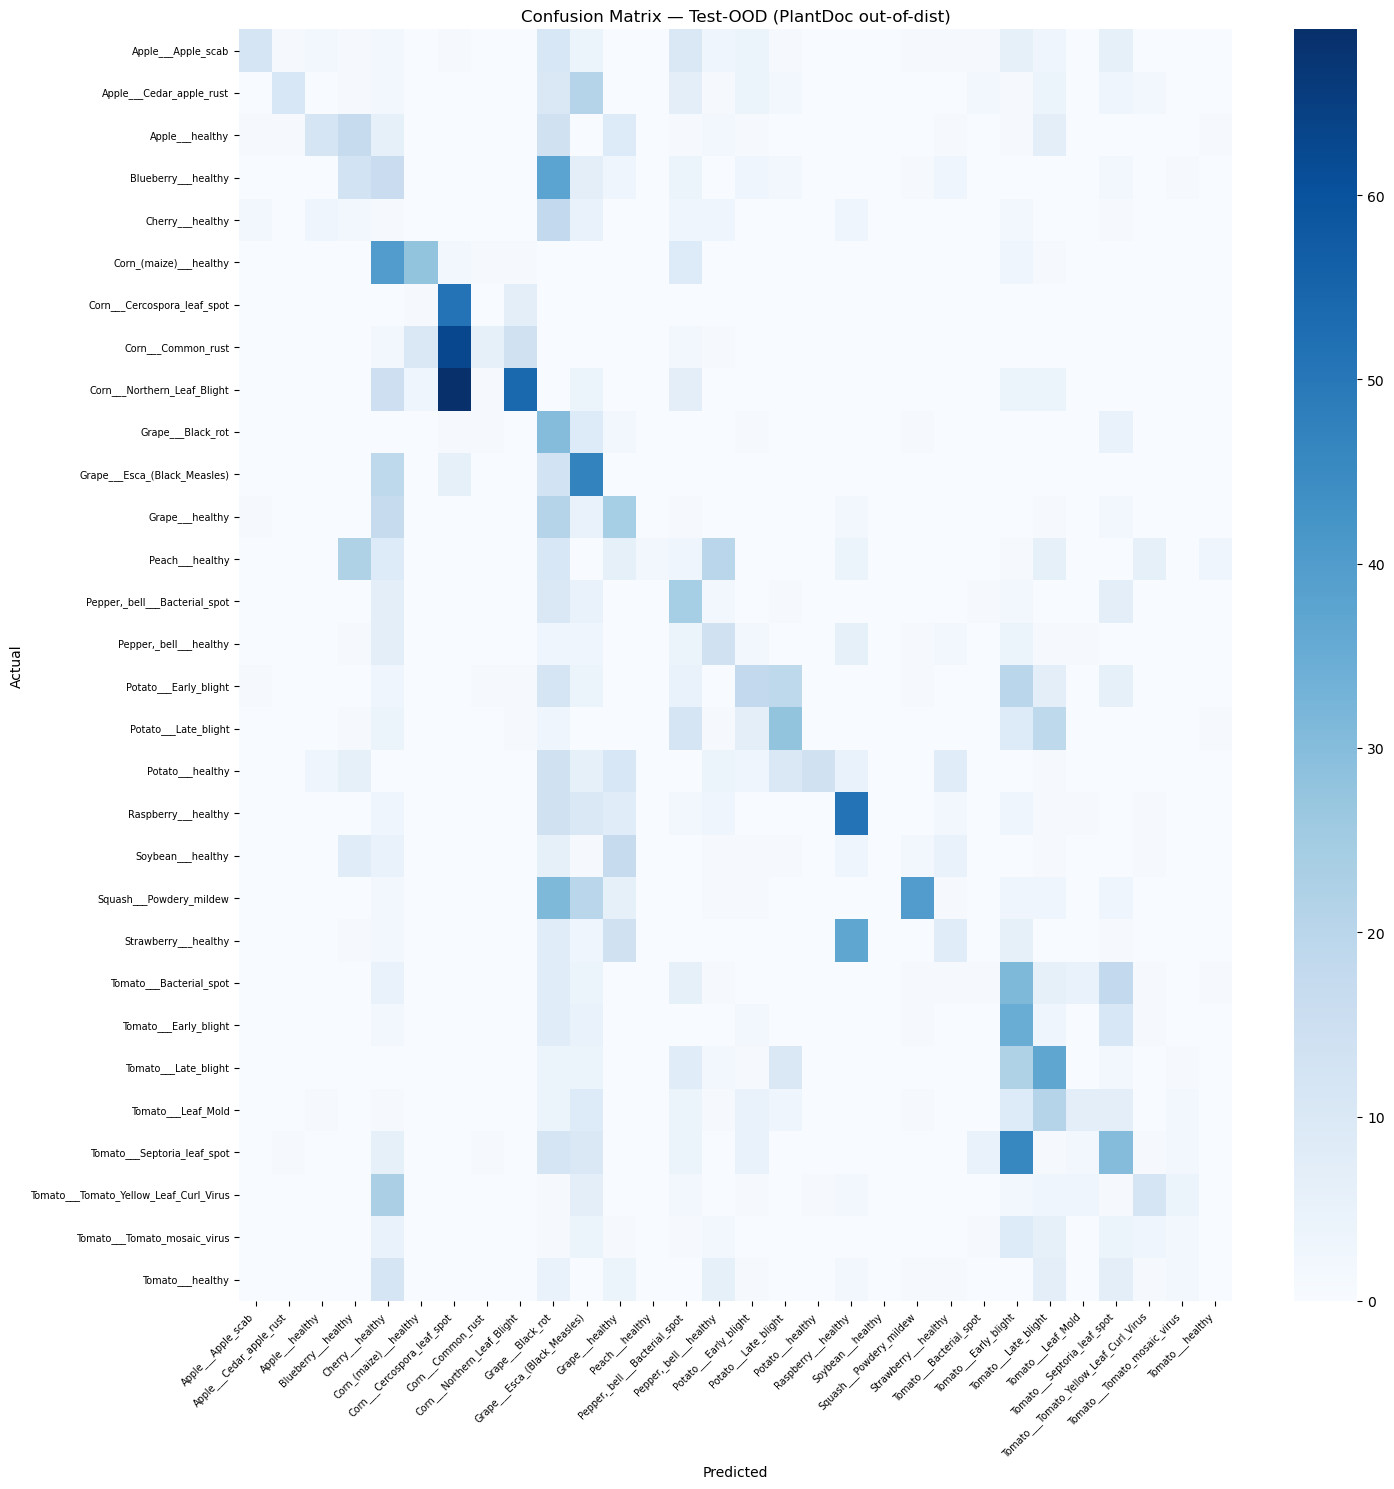


  Test-OOD (TTA ×7)
  Top-1 Accuracy : 0.2789  (27.89%)
  Top-5 Accuracy : 0.6074  (60.74%)

                                        precision    recall  f1-score   support

                    Apple___Apple_scab     0.7500    0.1714    0.2791        70
              Apple___Cedar_apple_rust     0.8333    0.1408    0.2410        71
                       Apple___healthy     0.5000    0.1486    0.2292        74
                   Blueberry___healthy     0.1974    0.1613    0.1775        93
                      Cherry___healthy     0.0052    0.0233    0.0085        43
                Corn_(maize)___healthy     0.7317    0.3529    0.4762        85
           Corn___Cercospora_leaf_spot     0.2591    0.8475    0.3968        59
                    Corn___Common_rust     0.8750    0.0714    0.1321        98
           Corn___Northern_Leaf_Blight     0.7403    0.3540    0.4790       161
                     Grape___Black_rot     0.1038    0.6600    0.1793        50
          Grape___Esca_(B

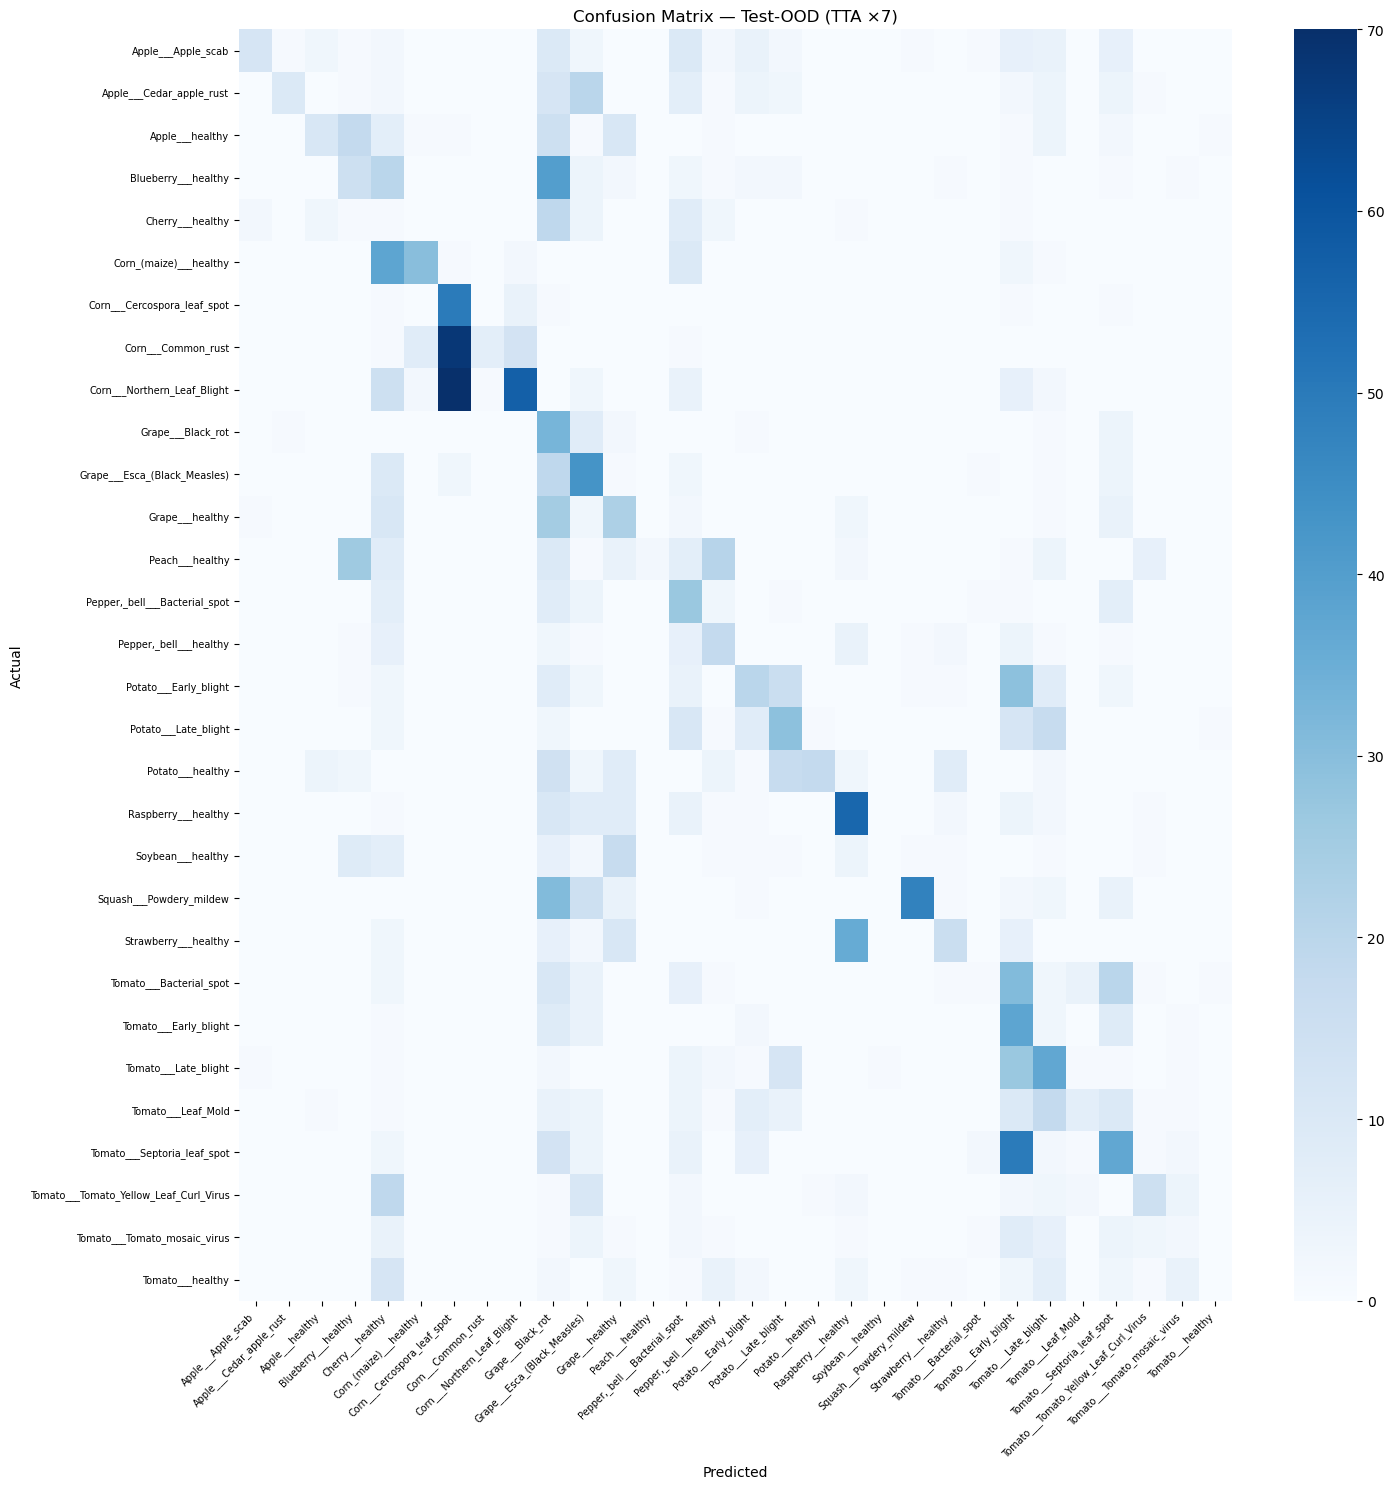

In [16]:
results_id      = full_evaluation(model, test_id_loader,  CLASS_NAMES,
                                   'Test-ID  (PlantVillage in-dist)')
results_ood     = full_evaluation(model, test_ood_loader,  CLASS_NAMES,
                                   'Test-OOD (PlantDoc out-of-dist)')
results_ood_tta = full_evaluation(model, test_ood_loader,  CLASS_NAMES,
                                   'Test-OOD', use_tta=True, tta_n=7)

Domain Generalization Summary

This is the headline result of the experiment. The **domain gap** is defined as:


Domain Gap = Test_ID Accuracy − Test_OOD Accuracy

In [ ]:
gap      = results_id['top1'] - results_ood['top1']
tta_gain = results_ood_tta['top1'] - results_ood['top1']

print("=" * 55)
print("  DOMAIN GENERALIZATION SUMMARY")
print("=" * 55)
print(f"  Test-ID  (in-distribution)  : {results_id['top1']:.4f}  ({100*results_id['top1']:.2f}%)")
print(f"  Test-OOD (out-of-dist)      : {results_ood['top1']:.4f}  ({100*results_ood['top1']:.2f}%)")
print(f"  Test-OOD + TTA  (×7)        : {results_ood_tta['top1']:.4f}  ({100*results_ood_tta['top1']:.2f}%)")
print(f"  TTA gain                    : +{tta_gain:.4f}  (+{100*tta_gain:.2f}%)")
print(f"  Domain gap (ID − OOD)       : {gap:.4f}  ({100*gap:.2f}%)")
print()

if gap > 0.25:
    print("  LARGE gap — few-shot fine-tuning is strongly recommended.")
elif gap > 0.10:
    print("  MODERATE gap — partial generalization achieved.")
else:
    print("  SMALL gap — strong generalization to real-world images!")

  DOMAIN GENERALIZATION SUMMARY
  Test-ID  (in-distribution)  : 0.9948  (99.48%)
  Test-OOD (out-of-dist)      : 0.2578  (25.78%)
  Test-OOD + TTA  (×7)        : 0.2789  (27.89%)
  TTA gain                    : +0.0211  (+2.11%)
  Domain gap (ID − OOD)       : 0.7370  (73.70%)

  ⚠️  LARGE gap — few-shot fine-tuning is strongly recommended.


Save Checkpoint

The model checkpoint is saved with all metadata embedded — class names, normalization
statistics, and evaluation results — so it can be loaded and deployed without
needing any other files.

In [18]:
SAVE_DIR = os.path.join(DATASET_ROOT, 'checkpoints')
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint = {
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'num_classes'      : NUM_CLASSES,
    'norm_mean'        : NORM_MEAN,
    'norm_std'         : NORM_STD,
    'img_size'         : IMG_SIZE,
    'results': {
        'test_id'      : {'top1': results_id['top1'],      'top5': results_id['top5']},
        'test_ood'     : {'top1': results_ood['top1'],     'top5': results_ood['top5']},
        'test_ood_tta' : {'top1': results_ood_tta['top1'], 'top5': results_ood_tta['top5']},
        'domain_gap'   : gap,
    }
}

save_path = os.path.join(SAVE_DIR, 'resnet50_plantlab2real.pth')
torch.save(checkpoint, save_path)
print(f"  Checkpoint saved to: {save_path}")
print(f"  File size          : {os.path.getsize(save_path) / 1e6:.1f} MB")

  Checkpoint saved to: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\checkpoints\resnet50_plantlab2real.pth
  File size          : 98.6 MB


Few-Shot Fine-Tuning

Activates automatically when the domain gap exceeds **20%**.

The `Few_Shot` split is divided **in-memory** into 80% train / 20% val to keep
`Test_OOD` completely untouched during fine-tuning. Only after fine-tuning is
complete is `Test_OOD` used for the final evaluation.

**Strategy:** Fine-tune only `layer4` + `fc` on the field images at very low LRs
to adapt the model to real-world visual characteristics without catastrophic
forgetting of the PlantVillage features.

> Set `FORCE_FEW_SHOT = True` to run regardless of the domain gap.

  Domain gap = 0.7370 → Running few-shot fine-tuning...

  Few_Shot total  : 300
  Fine-tune train : 240  (80%)
  Fine-tune val   : 60   (20%)  ← NO test leakage
  Test_OOD        : 2,374  ← untouched until final eval

  Unfrozen: ['layer4', 'fc']  →  16,030,238 / 24,573,534 params (65.2%)

  Few-Shot Fine-Tuning (val = Few_Shot 20%)
  Ep   1/15  train 2.8355/0.3375  val 3.0639/0.2000  (8s) ✓ improved
  Ep   2/15  train 2.6792/0.3583  val 3.0200/0.2167  (7s) ✓ improved
  Ep   3/15  train 2.4530/0.3708  val 2.9576/0.2000  (7s) ✓ improved
  Ep   4/15  train 2.5676/0.3583  val 2.8964/0.2167  (7s) ✓ improved
  Ep   5/15  train 2.3747/0.4208  val 2.8570/0.2333  (8s) ✓ improved
  Ep   6/15  train 2.2773/0.4708  val 2.7976/0.2500  (7s) ✓ improved
  Ep   7/15  train 2.1945/0.4542  val 2.7664/0.3000  (7s) ✓ improved
  Ep   8/15  train 2.0526/0.5208  val 2.7688/0.2833  (7s) [0/5]
  Ep   9/15  train 2.1295/0.4917  val 2.7192/0.3000  (7s) ✓ improved
  Ep  10/15  train 2.1920/0.4583  val 2.7096/0.3

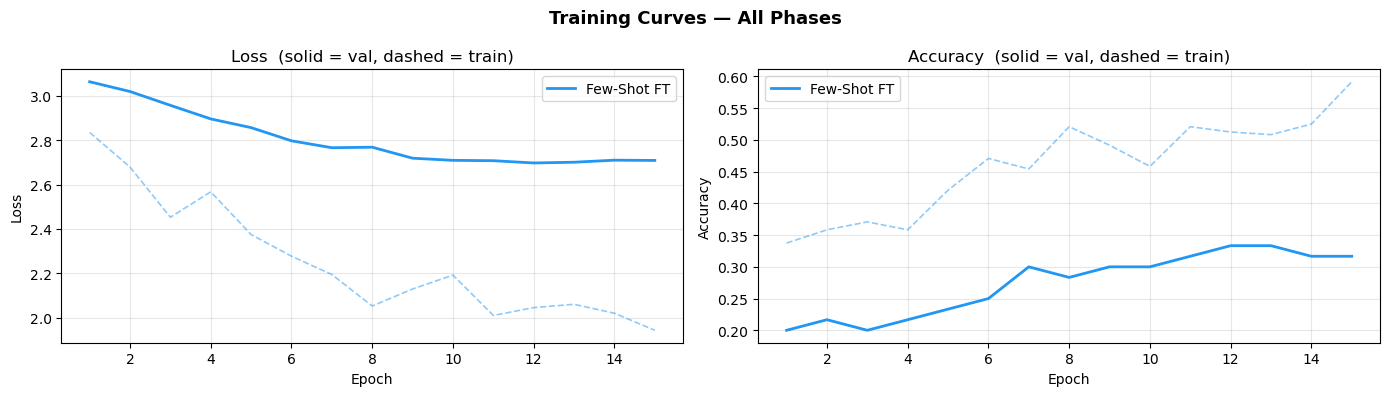


  Final OOD evaluation — Test_OOD used for the first time

  Test-OOD (after few-shot FT)
  Top-1 Accuracy : 0.4200  (42.00%)
  Top-5 Accuracy : 0.7570  (75.70%)

                                        precision    recall  f1-score   support

                    Apple___Apple_scab     0.6429    0.1286    0.2143        70
              Apple___Cedar_apple_rust     0.5682    0.3521    0.4348        71
                       Apple___healthy     0.4808    0.3378    0.3968        74
                   Blueberry___healthy     0.2039    0.2258    0.2143        93
                      Cherry___healthy     0.0615    0.1860    0.0925        43
                Corn_(maize)___healthy     0.7019    0.8588    0.7725        85
           Corn___Cercospora_leaf_spot     0.4561    0.4407    0.4483        59
                    Corn___Common_rust     0.7237    0.5612    0.6322        98
           Corn___Northern_Leaf_Blight     0.6667    0.5093    0.5775       161
                     Grape___Black_

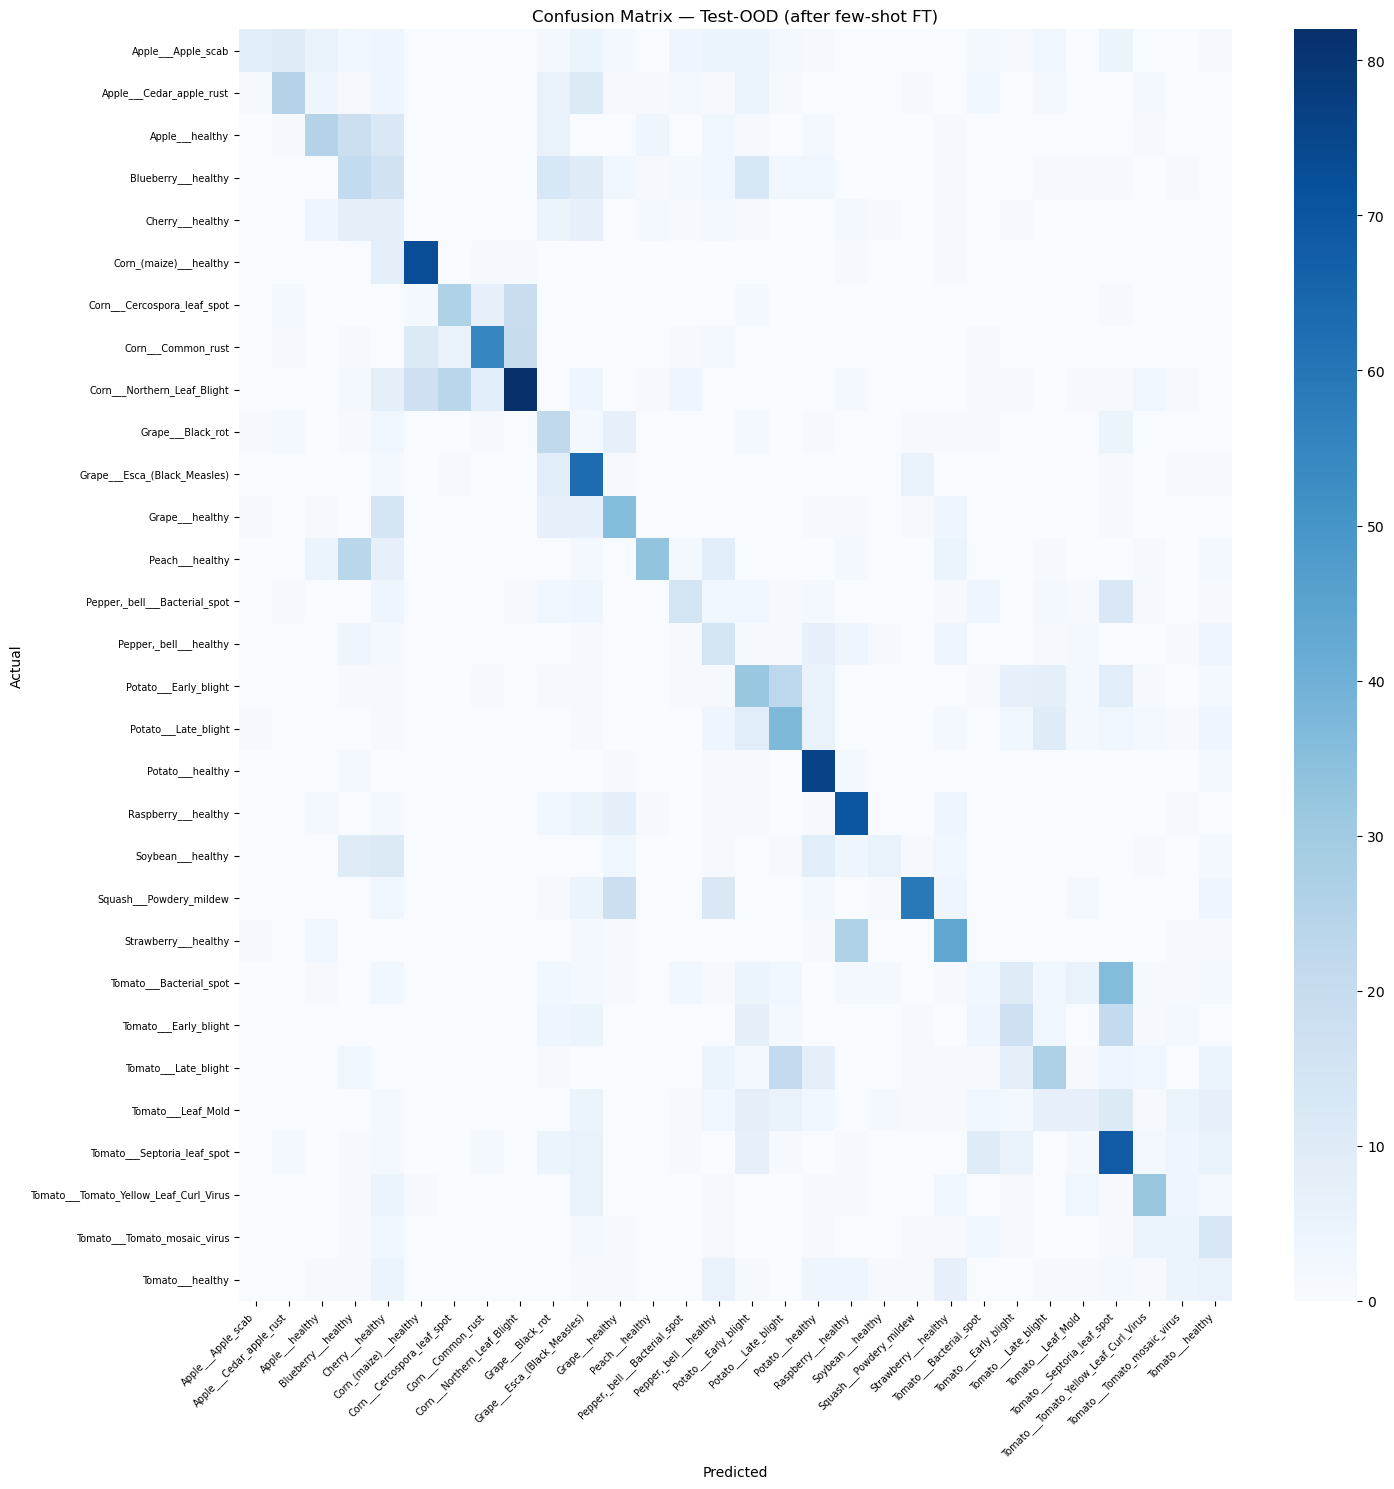


  OOD: 0.2578 → 0.4200  (+0.1622)

  Fine-tuned checkpoint saved: C:\Users\LA-Mahdis\Desktop\Maciek\ENEN-645\Final_Project\Dataset\checkpoints\resnet50_plantlab2real_finetuned.pth


In [20]:
FORCE_FEW_SHOT   = False
FEW_SHOT_VAL_PCT = 0.20          # 20% of Few_Shot held out for val
RUN_FEW_SHOT     = FORCE_FEW_SHOT or (gap > 0.20)

if RUN_FEW_SHOT:
    print(f"  Domain gap = {gap:.4f} → Running few-shot fine-tuning...\n")

    # Load Few_Shot with TRAIN augmentations for the training portion
    few_shot_full = datasets.ImageFolder(SPLITS['Few_Shot'], transform=train_transform)

    n_total = len(few_shot_full)
    n_val   = math.ceil(n_total * FEW_SHOT_VAL_PCT)
    n_train = n_total - n_val

    few_shot_train_ds, few_shot_val_ds = random_split(
        few_shot_full, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)   # reproducible split
    )

    #The val subset should NOT have heavy augmentation
    # Wrap the val subset with eval_transform via a simple dataset wrapper
    class SubsetWithTransform(torch.utils.data.Dataset):
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform
        def __len__(self):
            return len(self.subset)
        def __getitem__(self, idx):
            img, label = self.subset[idx]
            # img is already a tensor here (from train_transform);
            # reload from path to apply eval_transform cleanly
            path, label = self.subset.dataset.imgs[self.subset.indices[idx]]
            img = self.subset.dataset.loader(path)
            return self.transform(img), label

    few_shot_val_clean = SubsetWithTransform(few_shot_val_ds, eval_transform)

    few_shot_train_loader = DataLoader(
        few_shot_train_ds, batch_size=32, shuffle=True,
        num_workers=0, pin_memory=True
    )
    few_shot_val_loader   = DataLoader(
        few_shot_val_clean, batch_size=32, shuffle=False,
        num_workers=0, pin_memory=True
    )

    print(f"  Few_Shot total  : {n_total:,}")
    print(f"  Fine-tune train : {n_train:,}  ({100*(1-FEW_SHOT_VAL_PCT):.0f}%)")
    print(f"  Fine-tune val   : {n_val:,}   ({100*FEW_SHOT_VAL_PCT:.0f}%)  ← NO test leakage")
    print(f"  Test_OOD        : {len(test_ood_dataset):,}  ← untouched until final eval\n")

    #Fine-tune
    set_trainable_layers(model, ['layer4', 'fc'])

    opt_fs = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 5e-5},
        {'params': model.fc.parameters(),     'lr': 2e-4},
    ], weight_decay=0.01)
    sched_fs = optim.lr_scheduler.CosineAnnealingLR(opt_fs, T_max=15, eta_min=1e-7)
    es_fs    = EarlyStopping(patience=5)

    all_histories['Few-Shot FT'] = train_phase(
        model,
        few_shot_train_loader,
        few_shot_val_loader,    # ← Few_Shot val only, Test_OOD never seen here
        criterion, opt_fs, sched_fs, scaler, es_fs,
        max_epochs=15,
        phase_name='Few-Shot Fine-Tuning (val = Few_Shot 20%)'
    )
    plot_history({'Few-Shot FT': all_histories['Few-Shot FT']})

    #Final OOD evaluation — Test_OOD touched for the FIRST time
    print("\n" + "="*60)
    print("  Final OOD evaluation — Test_OOD used for the first time")
    print("="*60)
    results_ood_ft = full_evaluation(
        model, test_ood_loader, CLASS_NAMES,
        'Test-OOD (after few-shot FT)'
    )
    improvement = results_ood_ft['top1'] - results_ood['top1']
    print(f"\n  OOD: {results_ood['top1']:.4f} → {results_ood_ft['top1']:.4f}  "
          f"({'+'if improvement>=0 else ''}{improvement:.4f})")

    #Save fine-tuned checkpoint
    ft_path = os.path.join(SAVE_DIR, 'resnet50_plantlab2real_finetuned.pth')
    torch.save({
        **checkpoint,
        'model_state_dict'  : model.state_dict(),
        'few_shot_result'   : results_ood_ft['top1'],
        'few_shot_val_pct'  : FEW_SHOT_VAL_PCT,
    }, ft_path)
    print(f"\n  Fine-tuned checkpoint saved: {ft_path}")

else:
    print(f"  Domain gap = {gap:.4f} ≤ 0.20 → Few-shot fine-tuning skipped.")
    print("  Set FORCE_FEW_SHOT = True to run anyway.")

Grad-CAM Visualizations

Visualizing Grad-CAM on the final convolutional layer (`layer4[-1]`) for:
- **Test_ID** samples (PlantVillage) — expected clean, focused activations
- **Test_OOD** samples (PlantDoc) — reveals whether the model attends to
  the leaf or to background/lighting artifacts

Comparing ID vs OOD heatmaps directly diagnoses *why* the domain gap exists.

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(_, __, output):
            self.activations = output.detach()

        def backward_hook(_, __, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device)
        input_tensor.requires_grad_()

        output     = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # GAP over spatial dims
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.relu(cam)
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx


def overlay_heatmap(img_tensor, cam, alpha=0.45):
    """Overlay Grad-CAM heatmap on the original image."""
    # Denormalize
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    img  = img_tensor.cpu() * std + mean
    img  = img.clamp(0, 1).permute(1, 2, 0).numpy()
    img  = (img * 255).astype(np.uint8)

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap     = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    blended = (alpha * heatmap + (1 - alpha) * img).astype(np.uint8)
    return img, blended


def visualize_gradcam(model, dataset, gradcam, n_samples=6, split_name='Test', seed=42):
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(11, n_samples * 3.2))
    fig.suptitle(f'Grad-CAM Heatmaps — {split_name}', fontsize=13, fontweight='bold')

    for row, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        cam, pred_idx = gradcam.generate(img_tensor)

        original, overlay = overlay_heatmap(img_tensor, cam)
        pred_label  = CLASS_NAMES[pred_idx]
        true_label  = CLASS_NAMES[label]
        correct     = pred_idx == label

        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f'True: {true_label}', fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(cv2.resize(cam, (IMG_SIZE, IMG_SIZE)), cmap='jet')
        axes[row, 1].set_title('CAM (raw)', fontsize=8)
        axes[row, 1].axis('off')

        border_color = '#2e7d32' if correct else '#c62828'
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'Pred: {pred_label}', fontsize=8,
                               color='green' if correct else 'red')
        for spine in axes[row, 2].spines.values():
            spine.set_edgecolor(border_color); spine.set_linewidth(2)
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'gradcam_{split_name.replace(" ","_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved to: {SAVE_DIR}/gradcam_{split_name}.png")


# Attach Grad-CAM to last conv block of ResNet-50
gradcam = GradCAM(model, model.layer4[-1])

print("Generating Grad-CAM for Test_ID (in-distribution)...")
visualize_gradcam(model, test_id_dataset, gradcam,
                  n_samples=6, split_name='Test_ID')

print("\nGenerating Grad-CAM for Test_OOD (out-of-distribution)...")
visualize_gradcam(model, test_ood_dataset, gradcam,
                  n_samples=6, split_name='Test_OOD')